# Introduction
The following four topics will be discussed

- Financial Data
  -  data import
  -  summary statistics
  -  resampling
-  Rolling Statistics
  -  moving average
  
- Correlation Analysis
  - S&P 500 index and Vix relationship
  
- High Frequency data

## Data import from web: <font color='g'>Here yahoo finance</font>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.core.common.is_list_like = pd.api.types.is_list_like
from pandas_datareader import data as pdr
import yfinance as yf
# if wish to override hassle with pandas then use yf.download()

## Data import: from yahoo finance

In [ ]:
# tickers


In [ ]:
tickers = ['AAPL', 'MSFT', 'IBM', 'GOOG', "TSLA", "^GSPC", "^IXIC"]

In [ ]:
ticker = tickers[0]
aapl = yf.download('AAPL', "2020-01-01")

/tmp/ipython-input-733384583.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', "2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
aapl.columns = [x[0].lower() for x in aapl.columns]
aapl.head()

,close,high,low,open,volume
Date,,,,,
2020-01-02,72.538528,72.598907,71.292319,71.545905,135480400
2020-01-03,71.833298,72.594063,71.608692,71.765674,146322800
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200
2020-01-07,72.065140,72.671333,71.845362,72.415330,108872000
2020-01-08,73.224396,73.526287,71.768071,71.768071,132079200


## Data export as 'csv' file

In [ ]:
#aapl.to_csv("aapl.csv")

## Data import from csv file

In [ ]:
# import

#AAPL = pd.read_csv("c:/python/data/pff/AAPL.csv")

In [ ]:
df = pd.DataFrame()
for ticker in tickers:
    tmp = yf.download(ticker, "2020-01-01")['Close']
    tmp.columns =[x.lower() for x in tmp.columns]
    df[ticker]=tmp


/tmp/ipython-input-2916072013.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2916072013.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2916072013.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2916072013.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2916072013.py:3: FutureWarning: YF.download()

In [ ]:
df.head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-02,72.538528,152.791138,100.565186,67.903824,28.684000,3257.850098,9092.190430
2020-01-03,71.833282,150.888565,99.763168,67.570587,29.534000,3234.850098,9020.769531
2020-01-06,72.405670,151.278625,99.584961,69.236694,30.102667,3246.280029,9071.469727
2020-01-07,72.065140,149.899307,99.651772,69.193497,31.270666,3237.179932,9068.580078
2020-01-08,73.224411,152.286942,100.483521,69.738762,32.809334,3253.050049,9129.240234


In [ ]:
# save for later use

df.to_csv("your_directory")

# Preliminary Analysis


## Basic Statistics

In [ ]:
df.describe()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
count,1439.00,1439.00,1439.00,1439.00,1439.00,1439.00,1439.00
mean,160.19,307.84,142.97,127.35,227.36,4479.36,14172.12
std,45.41,94.99,52.78,38.45,88.16,931.21,3263.12
min,54.32,129.17,71.11,52.47,24.08,2237.40,6860.67
25%,130.40,234.97,107.67,98.14,180.32,3890.53,11682.38
50%,160.55,289.74,119.35,128.36,231.59,4352.63,13770.57
75%,190.66,398.01,173.42,153.31,281.81,5162.98,16197.94
max,258.10,534.76,292.80,255.24,479.86,6693.75,22788.98


In [ ]:
df.quantile(q=0.5)

,0.5
AAPL,160.550797
MSFT,289.736664
IBM,119.350929
GOOG,128.361588
TSLA,231.593338
^GSPC,4352.629883
^IXIC,13770.570312


## Plotting

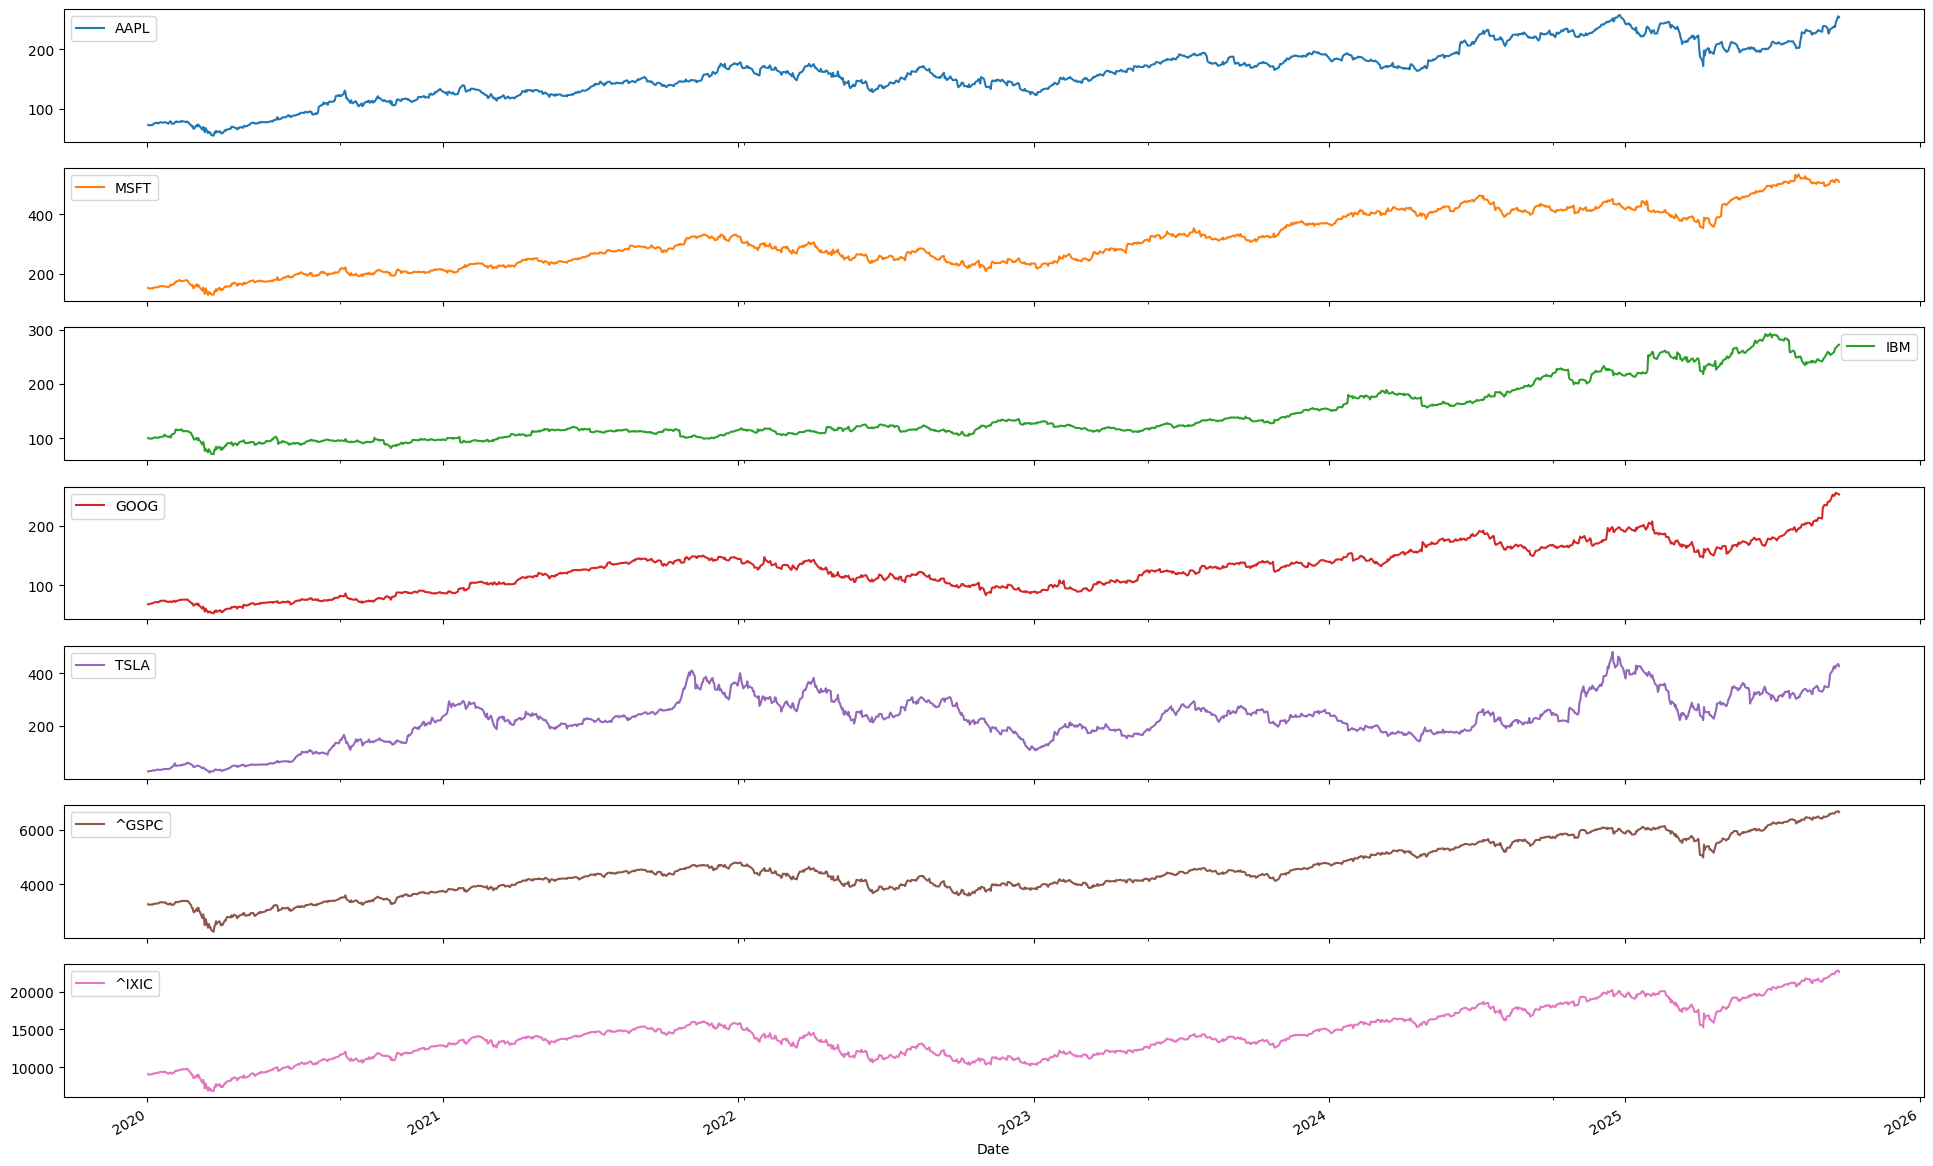

In [ ]:
#data_close.plot()
df.plot(subplots=True, figsize=(24,16))
plt.show()

## Rate of return related

In [ ]:
# percentage return

df.pct_change().dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-03,-0.009722,-0.012452,-0.007975,-0.004907,0.029633,-0.007060,-0.007855
2020-01-06,0.007968,0.002585,-0.001786,0.024657,0.019255,0.003533,0.005620
2020-01-07,-0.004703,-0.009118,0.000671,-0.000624,0.038801,-0.002803,-0.000319
2020-01-08,0.016086,0.015928,0.008347,0.007880,0.049205,0.004902,0.006689
2020-01-09,0.021241,0.012493,0.010568,0.011045,-0.021945,0.006655,0.008127


In [ ]:
# log return

np.log(df/df.shift(1)).dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-03,-0.009770,-0.012530,-0.008007,-0.004920,0.029203,-0.007085,-0.007886
2020-01-06,0.007937,0.002582,-0.001788,0.024358,0.019072,0.003527,0.005605
2020-01-07,-0.004714,-0.009160,0.000671,-0.000624,0.038067,-0.002807,-0.000319
2020-01-08,0.015958,0.015803,0.008312,0.007849,0.048033,0.004890,0.006667
2020-01-09,0.021018,0.012416,0.010513,0.010984,-0.022189,0.006633,0.008094


In [ ]:
# differnce

df.diff().dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-03,-0.705246,-1.902573,-0.802017,-0.333237,0.850000,-23.000000,-71.420898
2020-01-06,0.572388,0.390060,-0.178207,1.666107,0.568666,11.429932,50.700195
2020-01-07,-0.340530,-1.379318,0.066811,-0.043198,1.167999,-9.100098,-2.889648
2020-01-08,1.159271,2.387634,0.831749,0.545265,1.538668,15.870117,60.660156
2020-01-09,1.555344,1.902527,1.061913,0.770233,-0.720001,21.649902,74.189453


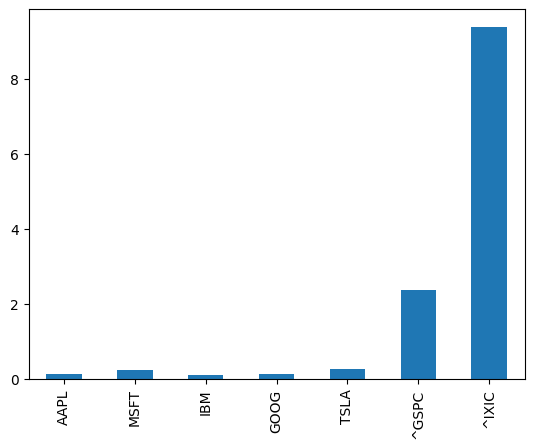

In [ ]:
# plot difference mean histogram

df.diff().dropna().mean().plot(kind='bar');

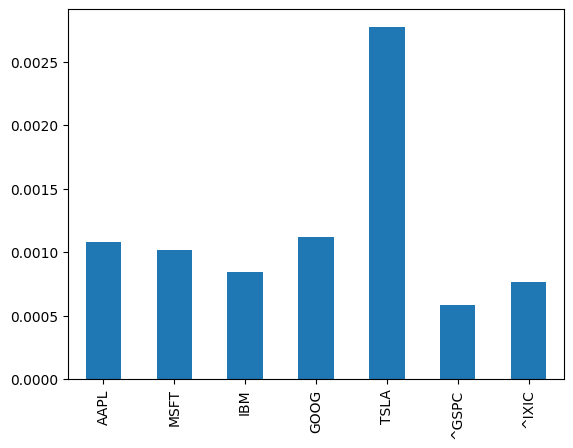

In [ ]:
df.pct_change().dropna().mean().plot(kind='bar');

<Axes: xlabel='Date'>

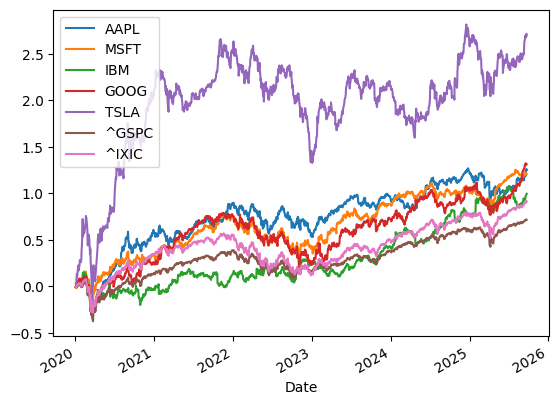

In [ ]:
ret = np.log(df/df.shift(1)).dropna()
ret.cumsum().plot()

<Axes: xlabel='Date'>

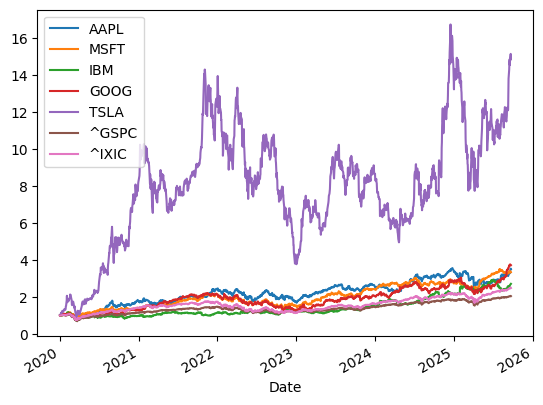

In [ ]:
ret.cumsum().apply(np.exp).plot()   # why exp?

**Cumulative return**
\begin{align*}
\exp\left[log \left(\ 1+ \frac{p_t - p_{t-1}}{p_{t-1}}    \right).cumsum  \right] -1
\end{align*}  

<Axes: xlabel='Date'>

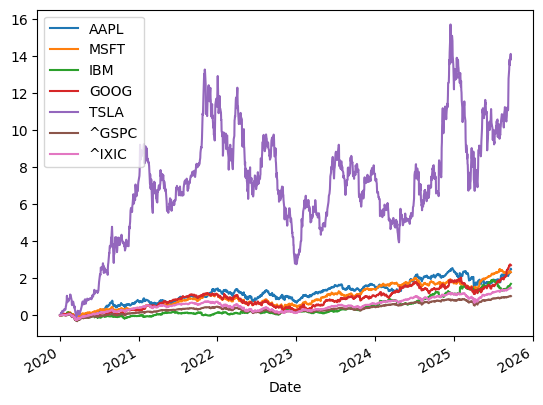

In [ ]:
ret = df.pct_change()
cum_ret = np.exp(np.log(1+ret).cumsum())-1
cum_ret.plot()

# Resampling

In [ ]:
df.resample('1w', label='right').first().head()

/tmp/ipython-input-750673998.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df.resample('1w', label='right').first().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-05,72.538528,152.791138,100.565186,67.903824,28.684000,3257.850098,9092.190430
2020-01-12,72.405670,151.278625,99.584961,69.236694,30.102667,3246.280029,9071.469727
2020-01-19,76.550049,155.321472,101.441460,71.472389,34.990665,3288.129883,9273.929688
2020-01-26,76.455849,158.384552,103.349991,73.715546,36.480000,3320.790039,9370.809570
2020-02-02,74.615547,154.370209,102.941544,71.207710,37.201332,3243.629883,9139.309570


In [ ]:
df.resample('1w', label='right').last().head()

/tmp/ipython-input-1009130987.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df.resample('1w', label='right').last().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-05,71.833282,150.888565,99.763168,67.570587,29.534000,3234.850098,9020.769531
2020-01-12,74.948830,153.476074,101.508316,71.000633,31.876667,3265.350098,9178.860352
2020-01-19,76.977524,158.955276,102.711365,73.516403,34.033333,3329.620117,9388.940430
2020-01-26,76.876091,156.995697,104.382240,72.837051,37.654667,3295.469971,9314.910156
2020-02-02,74.750801,161.932755,106.736320,71.224091,43.371334,3225.520020,9150.940430


In [ ]:
df.index.weekday

Index([3, 4, 0, 1, 2, 3, 4, 0, 1, 2,
       ...
       2, 3, 4, 0, 1, 2, 3, 4, 0, 1],
      dtype='int32', name='Date', length=1439)

In [ ]:
df.resample('M', label='left', closed='left').last().head()

/tmp/ipython-input-4221010652.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', label='left', closed='left').last().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2019-12-31,78.218895,164.358414,101.567719,72.297256,42.720669,3283.659912,9298.929688
2020-01-31,66.176735,154.534332,97.660851,66.511345,44.532665,2954.219971,8567.370117
2020-02-29,61.686050,152.836395,84.739441,56.951267,33.475334,2626.649902,7774.149902
2020-03-31,69.655510,169.242767,96.565300,66.618118,53.367332,2939.510010,8914.709961
2020-04-30,77.177322,175.281067,94.978317,70.960403,55.666668,3044.310059,9489.870117


/tmp/ipython-input-1020566399.py:3: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax = ret.cumsum().resample('m').last().plot()


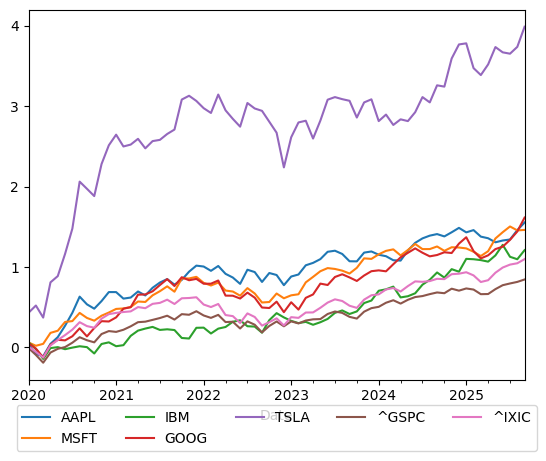

In [ ]:
#ret.index = pd.to_datetime(ret.index)

ax = ret.cumsum().resample('m').last().plot()
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)
#ax.legend(loc='center left')

#ret.cumsum().resample('m').last().plot(figsize=(16,9))

# Rolling Statistics

In [ ]:
#df['min'] = df.rolling(window=20).min()
#df['max'] = df.rolling(window=20).max()
tsla_mean = df['TSLA'].rolling(20).mean()

<Axes: xlabel='Date'>

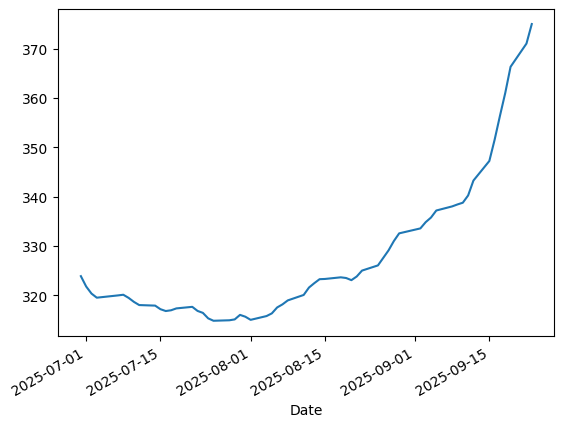

In [ ]:
tsla_mean[-60:].plot()

In [ ]:
df2 = df['TSLA'].copy()
df2 = pd.DataFrame(df2)
df2.index =  pd.to_datetime(df.index)
df2.columns = ['close']
df2 = df2.dropna()

In [ ]:
df2.head()

,close,sma20
Date,,
2020-01-02,28.684000,NaN
2020-01-03,29.534000,NaN
2020-01-06,30.102667,NaN
2020-01-07,31.270666,NaN
2020-01-08,32.809334,NaN


In [ ]:
df2['sma20'] = df2['close'].rolling(20).mean()
df2['sma60'] = df2['close'].rolling(60).mean()

In [ ]:
df2['position'] = list(map(lambda x,y: [-1,1][x>y], df2['sma20'], df2['sma60']))
df2['position2'] = np.where(df2['sma20']>df2['sma60'], 1, -1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

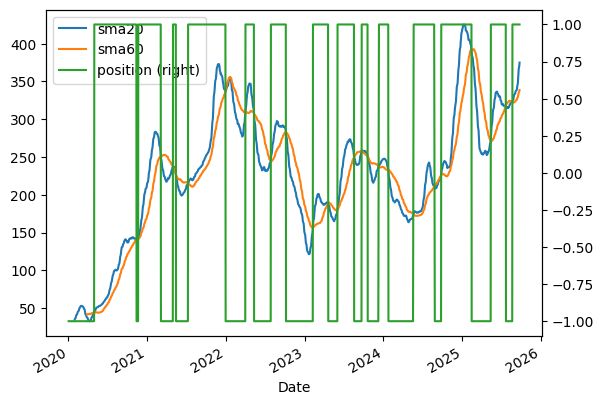

In [ ]:
%matplotlib inline
df2[['sma20', 'sma60', 'position']].plot(secondary_y = 'position')
plt.show()

# Correlation Analysis

In [ ]:
vix = yf.download('^VIX', "2020-01-01")
vix = vix['Close']
vix.columns =['VIX']
df['VIX']= vix

/tmp/ipython-input-2476782146.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', "2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
data_index = df[['^GSPC', 'VIX']]
data_index = data_index.dropna()
data_index.head()

,^GSPC,VIX
Date,,
2020-01-02,3257.850098,12.47
2020-01-03,3234.850098,14.02
2020-01-06,3246.280029,13.85
2020-01-07,3237.179932,13.79
2020-01-08,3253.050049,13.45


<Axes: xlabel='Date'>

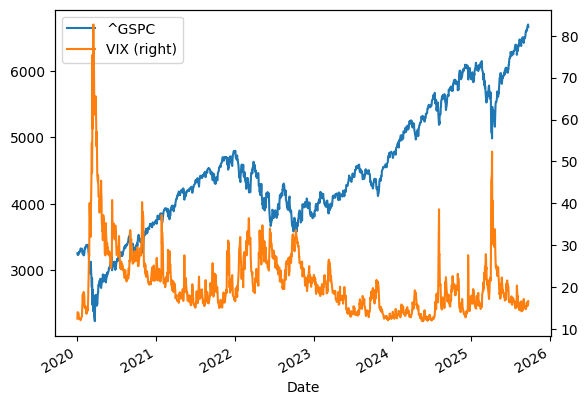

In [ ]:
data_index.plot(secondary_y='VIX')

In [ ]:
ret_index = data_index.pct_change()
ret_index = ret_index.dropna()

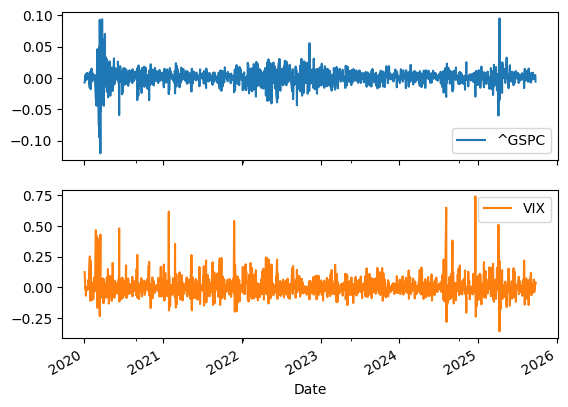

In [ ]:
%matplotlib inline

ret_index.plot(subplots=True);

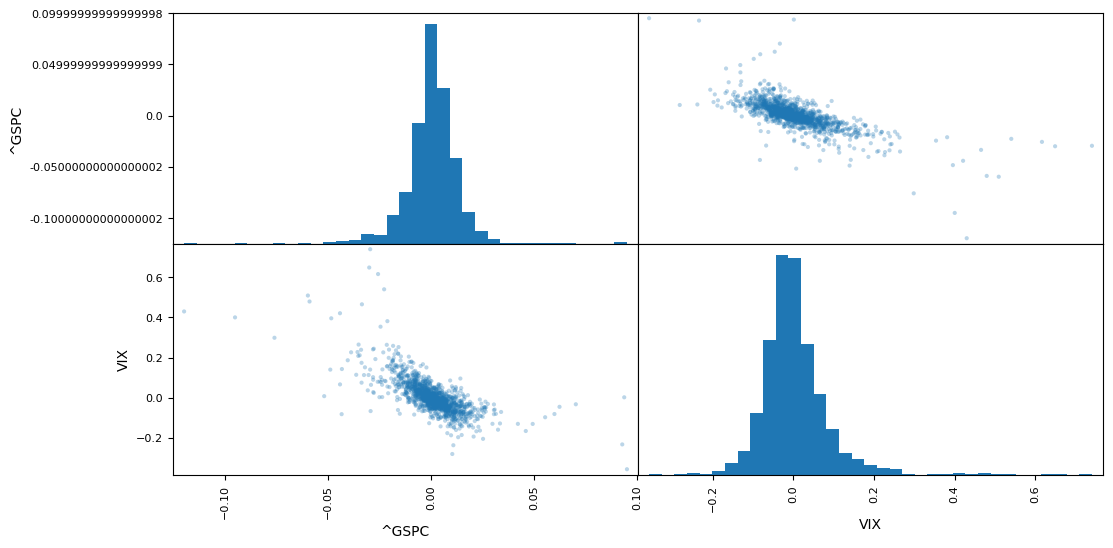

In [ ]:
pd.plotting.scatter_matrix(ret_index, diagonal='hist', figsize=(12,6), hist_kwds={'bins': 35}, alpha=0.3);

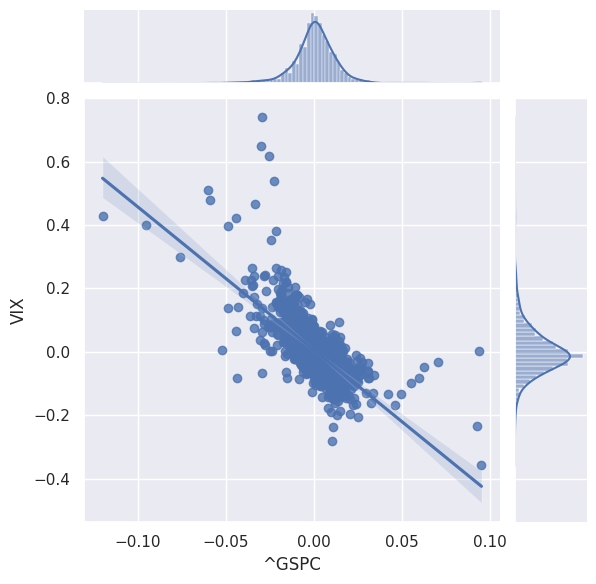

In [ ]:
import seaborn as sns;  sns.set()

sns.jointplot(x='^GSPC', y='VIX', data=ret_index, kind='reg')

In [ ]:
rets_corr = ret_index.corr()
rets_corr

,^GSPC,VIX
^GSPC,1.000000,-0.714464
VIX,-0.714464,1.000000


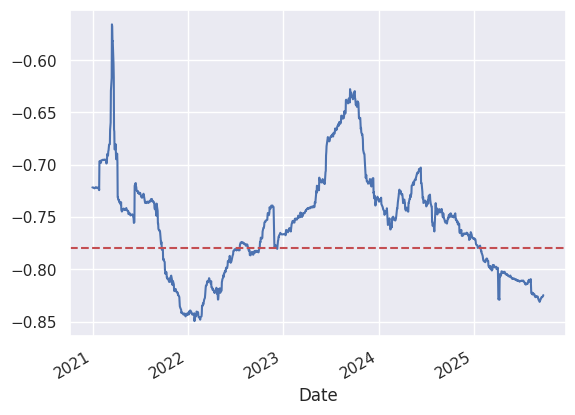

In [ ]:
ax= ret_index['^GSPC'].rolling(window=252).corr(ret_index['VIX']).plot()
#ax.axvline(rets_corr.iloc[0,1])
ax.axhline(y=-0.78, c='r', ls='--')